In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import optuna
import numpy as np
import sys, os, time
import torch
import torch.nn as nn
import data, architecture
import optuna
from torch.utils.data import random_split, DataLoader

## Get results files

In [13]:
################################### INPUT ############################################
# data parameters
f_Pk_norm = None #file with Pk to normalize Pk
seed      = 42         #seed to split data in train/valid/test
# mode      = 'all'   #modes looped through later

cosm_type = 'BSQ'
Pk_type = 'Pk'
output_size = 6
all_n_sims = [22000]
# all_n_sims_BSQ = [0, 2000, 4000]
all_n_sims_BSQ = [0]

additional_extension = '_node' #fixed test valid size

## leander fine tune test

In [14]:
# for n_sims_BSQ in all_n_sims_BSQ:
#     for n_sims in all_n_sims:
#         # NAME (depending on network 1 or 2)
#         name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ' + additional_extension  #_fixed for fixed test/valid set
        
#         # OTHER EXTENSIONS
#         params_ext = ''  
#         f_params  = '../real_params/'+'all_'+str(cosm_type)+'_params'+params_ext+'.txt' 

#         log        = True 
#         input_size = 79
#         model_type = 'dynamic_fixed_final'
#         f_Pk       = 'Pk_files/'+'all_'+str(Pk_type)+'_'+str(cosm_type)+params_ext+'.npy'
#         final_hidden_layer_size = 10
            

#         # INFO THAT DOES NOT CHANGE
#         study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
#         mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'
        
#         print(name)
#         print(f_params)
#         print(f_Pk)
#         print(study_name)
        
#         # architecture parameters
#         # training parameters
#         batch_size = 32
#         # optuna parameters
#         storage    = 'sqlite:///nwLH.db'
        
#         ######################################################################################
#         ## LOAD MODEL
        
#         # use GPUs if available
#         if torch.cuda.is_available():
#             print("CUDA Available")
#             device = torch.device('cuda')
#         else:
#             print('CUDA Not Available')
#             device = torch.device('cpu')


#         ################### OPTUNA BEST STUDY LOAD #################
#         BSQ_name = 'transfer10_network1_'+str(n_sims_BSQ)+'_BSQ_fixed'
#         BSQ_study_name = 'Pk_BSQ_params_'+BSQ_name
#         BSQ_study = optuna.load_study(study_name=BSQ_study_name, storage=storage)
#         values = np.zeros(len(BSQ_study.trials))
#         completed = 0
#         for i,t in enumerate(BSQ_study.trials):
#             values[i] = t.value
#             if t.value is not None:  completed += 1
#         indexes = np.argsort(values)
#         for i in [0]:  #choose the best-model here, e.g. [0], or [1]
#             BSQ_best_trial = BSQ_study.trials[indexes[i]]
#             BSQ_lr       = BSQ_best_trial.params['lr']
#             BSQ_wd       = BSQ_best_trial.params['wd']
#             BSQ_n_layers       = BSQ_best_trial.params['n_layers']
#             BSQ_p       = BSQ_best_trial.params['dropout_l']
#             BSQ_out_fs = [BSQ_best_trial.params[f'n_units_l{i}'] for i in range(BSQ_n_layers - 1)]
#             BSQ_out_fhl = 10

        
        
#         # load the optuna study
#         study = optuna.load_study(study_name=study_name, storage=storage)
#         # get the scores of the study trials
#         values = np.zeros(len(study.trials))
#         completed = 0
#         for i,t in enumerate(study.trials):
#             values[i] = t.value
#             if t.value is not None:  completed += 1

#         # get the info of the best trial            
#         indexes = np.argsort(values)
#         for i in [0]:  #choose the best-model here, e.g. [0], or [1]
#             trial = study.trials[indexes[i]]
#             print("\nTrial number {}".format(trial.number))
#             print("Value: %.5e"%trial.value)
#             print(" Params: ")
#             for key, value in trial.params.items():
#                 print("    {}: {}".format(key, value))
#             lr       = trial.params['lr']
#             wd       = trial.params['wd']
#             # n_layers       = trial.params['n_layers']
#             n_layers = BSQ_n_layers
#             p = BSQ_p
#             out_fs = BSQ_out_fs
#             # p       = trial.params['dropout_l']
#             fmodel = mother +'model_%d.pt'%trial.number
        
#         ## generate the architecture
#         # out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
#         model = architecture.dynamic_model_fixed_final(trial, input_size, output_size, 
#                                                        final_hidden_layer_size, 
#                                                        n_layers, p, out_fs,
#                                                        max_neurons_layers=500) 

        
#         model.to(device)  
#         # load best-model, if it exists
#         if os.path.exists(fmodel):  
#             print('Loading model...')
#             model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
#         else:
#             raise Exception('model doesnt exists!!!')
        
#         # define loss function
#         criterion = nn.MSELoss() 


#         ## GET TRAIN, VALID, TEST RESULTS
#         for mode in ['all', 'train', 'valid', 'test']:
#             # get the data
#             if mode == 'train':
#                     # get the data
#                     full_train_dataset = data.create_dataset('train', seed, f_Pk, f_Pk_norm, 
#                                                        f_params, batch_size, shuffle=False, 
#                                                        workers=1, cosm_type = cosm_type, log=log, 
#                                                        shuffle_all=True).dataset
#                     train_subset, _ = torch.utils.data.random_split(full_train_dataset,
#                                                                     [n_sims, len(full_train_dataset) - n_sims],
#                                                                     generator=torch.Generator().manual_seed(seed)
#                                                                    )
#                     test_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
#             else:
#                 test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
#                                               batch_size, shuffle=False, workers=1, 
#                                               cosm_type =cosm_type, log=log, 
#                                               shuffle_all = True)
            
                
            
#             test_points = 0
#             for x,y in test_loader:  test_points += x.shape[0]
            
#             # define the arrays containing the true and predicted value of the parameters
#             params  = output_size
#             results = np.zeros((test_points, 2*params), dtype=np.float32)
            
#             # test the model
#             test_loss, points = 0.0, 0
#             model.eval()
#             with torch.no_grad():
#                 for x, y in test_loader:
#                     bs   = x.shape[0]  #batch size
#                     x, y = x.to(device), y.to(device)
#                     y_NN = model(x)
#                     test_loss += (criterion(y_NN, y).item())*bs
#                     results[points:points+bs,0*params:1*params] = y.cpu().numpy()
#                     results[points:points+bs,1*params:2*params] = y_NN.cpu().numpy()
#                     points    += bs
#             test_loss /= points
#             print('Test loss:', test_loss)
            
#             # denormalize results here
#             #
#             #
            
#             # save results to file
#             fout = 'results/Results_'+mode+'_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'.txt'
#             np.savetxt(fout, results)
            
            
            
                    

## Standard

In [24]:
################################### INPUT ############################################
# data parameters
f_Pk_norm = None #file with Pk to normalize Pk
seed      = 42         #seed to split data in train/valid/test
# mode      = 'all'   #modes looped through later

cosm_type = 'BSQ'
Pk_type = 'Pk'
output_size = 6
all_n_sims = [22000]
# all_n_sims_BSQ = [0, 2000, 4000]
all_n_sims_BSQ = [0]

additional_extension = '_node' #fixed test valid size

In [27]:
for n_sims_BSQ in all_n_sims_BSQ:
    for n_sims in all_n_sims:
        # NAME (depending on network 1 or 2)
        if cosm_type == 'BSQ':
            name = 'transfer10_network1_'+str(n_sims)+'_BSQ' + additional_extension
        else:
            name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set
        
        # OTHER EXTENSIONS
        if cosm_type =='fR':
            params_ext = '_lcdm'  #_lcdm or _MGfor fR
        else:
            params_ext = ''  
        f_params  = '../real_params/'+'all_'+str(cosm_type)+'_params'+params_ext+'.txt' 

        # OTHER TRIAL INFO
        if cosm_type == 'BSQ':
            log        = True 
            input_size = 79
            model_type = 'dynamic_fixed_final'
            f_Pk       = 'Pk_files/'+'all_'+str(Pk_type)+'_'+str(cosm_type)+params_ext+'.npy'
            final_hidden_layer_size = 10
            
        elif n_sims_BSQ == 0:
            log         = True
            input_size  = 79 
            model_type  = 'dynamic'
            f_Pk        = 'Pk_files/'+'all_'+str(Pk_type)+'_'+str(cosm_type)+params_ext+'.npy'

        else:
            log         = False
            input_size  = 10
            model_type  = 'dynamic'
            extension   = 'fhl10'
            f_Pk        = 'Pk_files/'+'all_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ_'+Pk_type+params_ext+'_'+str(extension)+'_fortransfer'+additional_extension+'.npy'

        

        # INFO THAT DOES NOT CHANGE
        study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
        mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'
        
        print(name)
        print(f_params)
        print(f_Pk)
        print(study_name)
        
        # architecture parameters
        # training parameters
        batch_size = 32
        # optuna parameters
        storage    = 'sqlite:///nwLH.db'
        
        ######################################################################################
        ## LOAD MODEL
        
        # use GPUs if available
        if torch.cuda.is_available():
            print("CUDA Available")
            device = torch.device('cuda')
        else:
            print('CUDA Not Available')
            device = torch.device('cpu')
        
        # load the optuna study
        study = optuna.load_study(study_name=study_name, storage=storage)
        # get the scores of the study trials
        values = np.zeros(len(study.trials))
        completed = 0
        for i,t in enumerate(study.trials):
            values[i] = t.value
            if t.value is not None:  completed += 1


        # get the info of the best trial            
        indexes = np.argsort(values)
        for i in [0]:  #choose the best-model here, e.g. [0], or [1]
            trial = study.trials[indexes[i]]
            print("\nTrial number {}".format(trial.number))
            print("Value: %.5e"%trial.value)
            print(" Params: ")
            for key, value in trial.params.items():
                print("    {}: {}".format(key, value))
            lr       = trial.params['lr']
            wd       = trial.params['wd']
            n_layers       = trial.params['n_layers']
            p       = trial.params['dropout_l']
            
            '''comment h1 and dr out for dynamic models'''
            # h1       = trial.params['h1']
            # dr       = trial.params['dr']
            fmodel = mother +'model_%d.pt'%trial.number
        
        ## generate the architecture
        if model_type == 'dynamic_fixed_final':
            out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
            model = architecture.dynamic_model_fixed_final(trial, input_size, output_size, 
                                                           final_hidden_layer_size, 
                                                           n_layers, p, out_fs,
                                                           max_neurons_layers=500)
        elif model_type == 'dynamic':
            out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers)]
            model = architecture.dynamic_model(trial, input_size, output_size,
                                               n_layers, p, out_fs,
                                               max_neurons_layers=500)   
        else:
            print('not a valid model')
        
        model.to(device)  
        # load best-model, if it exists
        if os.path.exists(fmodel):  
            print('Loading model...')
            model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
        else:
            raise Exception('model doesnt exists!!!')
        
        # define loss function
        criterion = nn.MSELoss() 


        ## GET TRAIN, VALID, TEST RESULTS
        for mode in ['all', 'train', 'valid', 'test']:
            # get the data
            if mode == 'train':
                    # get the data
                    full_train_dataset = data.create_dataset('train', seed, f_Pk, f_Pk_norm, 
                                                       f_params, batch_size, shuffle=False, 
                                                       workers=1, cosm_type = cosm_type, log=log, 
                                                       shuffle_all=True).dataset
                    train_subset, _ = torch.utils.data.random_split(full_train_dataset,
                                                                    [n_sims, len(full_train_dataset) - n_sims],
                                                                    generator=torch.Generator().manual_seed(seed)
                                                                   )
                    test_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
            else:
                test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
                                              batch_size, shuffle=False, workers=1, 
                                              cosm_type =cosm_type, log=log, 
                                              shuffle_all = True)
            
                
            
            test_points = 0
            for x,y in test_loader:  test_points += x.shape[0]
            
            # define the arrays containing the true and predicted value of the parameters
            params  = output_size
            params = 5
            results = np.zeros((test_points, 2*params), dtype=np.float32)
            
            # test the model
            test_loss, points = 0.0, 0
            model.eval()
            with torch.no_grad():
                for x, y in test_loader:
                    bs   = x.shape[0]  #batch size
                    x, y = x.to(device), y.to(device)
                    y_NN = model(x)
                    if cosm_type == 'BSQ' and additional_extension == '_node':
                        y_NN = y_NN[:, :5]
                        test_loss += (criterion(y_NN, y).item())*bs
                    else:
                        test_loss += (criterion(y_NN, y).item())*bs  
                    # test_loss += (criterion(y_NN, y).item())*bs

                    results[points:points+bs, 0*params : 1*params] = y.cpu().numpy()           # shape (bs, 5)
                    results[points:points+bs, 1*params : 2*params] = y_NN.cpu().numpy()        # shape (bs, 5)

        
                    points    += bs
            test_loss /= points
            print('Test loss:', test_loss)
            
            # denormalize results here
            #
            #
            
            # save results to file
            fout = 'results/Results_'+mode+'_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'.txt'
            np.savetxt(fout, results)
            
            
            
                    

transfer10_network1_22000_BSQ_node
../real_params/all_BSQ_params.txt
Pk_files/all_Pk_BSQ.npy
Pk_BSQ_params_transfer10_network1_22000_BSQ_node
CUDA Available

Trial number 1
Value: 1.63639e-02
 Params: 
    lr: 0.001383294235425494
    wd: 2.4752044381361967e-07
    n_layers: 3
    dropout_l: 0.31859066274893316
    n_units_l0: 226
    n_units_l1: 169
Loading model...
Test loss: 0.01620010324753821
Test loss: 0.016166384291919796
Test loss: 0.016363891170670587
Test loss: 0.016265886183828116


## Make test true vs predicted plots for multiple n sims

In [17]:
cosm_type = 'nwLH'
Pk_type = 'Pk'
all_n_sims = [25, 50,150, 200, 400, 800, 1400]
n_sims_BSQ = 22000
additional_extension = '_fixed_ft_test'

In [18]:
if cosm_type == 'nwLH':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''

elif cosm_type == 'LH':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'BSQ':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'LC':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{local}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -300])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 300])
    params_ext = ''

elif cosm_type == 'EQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{equilateral}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -600])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 600])
    params_ext = ''

elif cosm_type == 'nwLH_BSQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''


elif cosm_type == 'fR':
    num_params = 7
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$f_{R}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
    params_ext = '_lcdm'


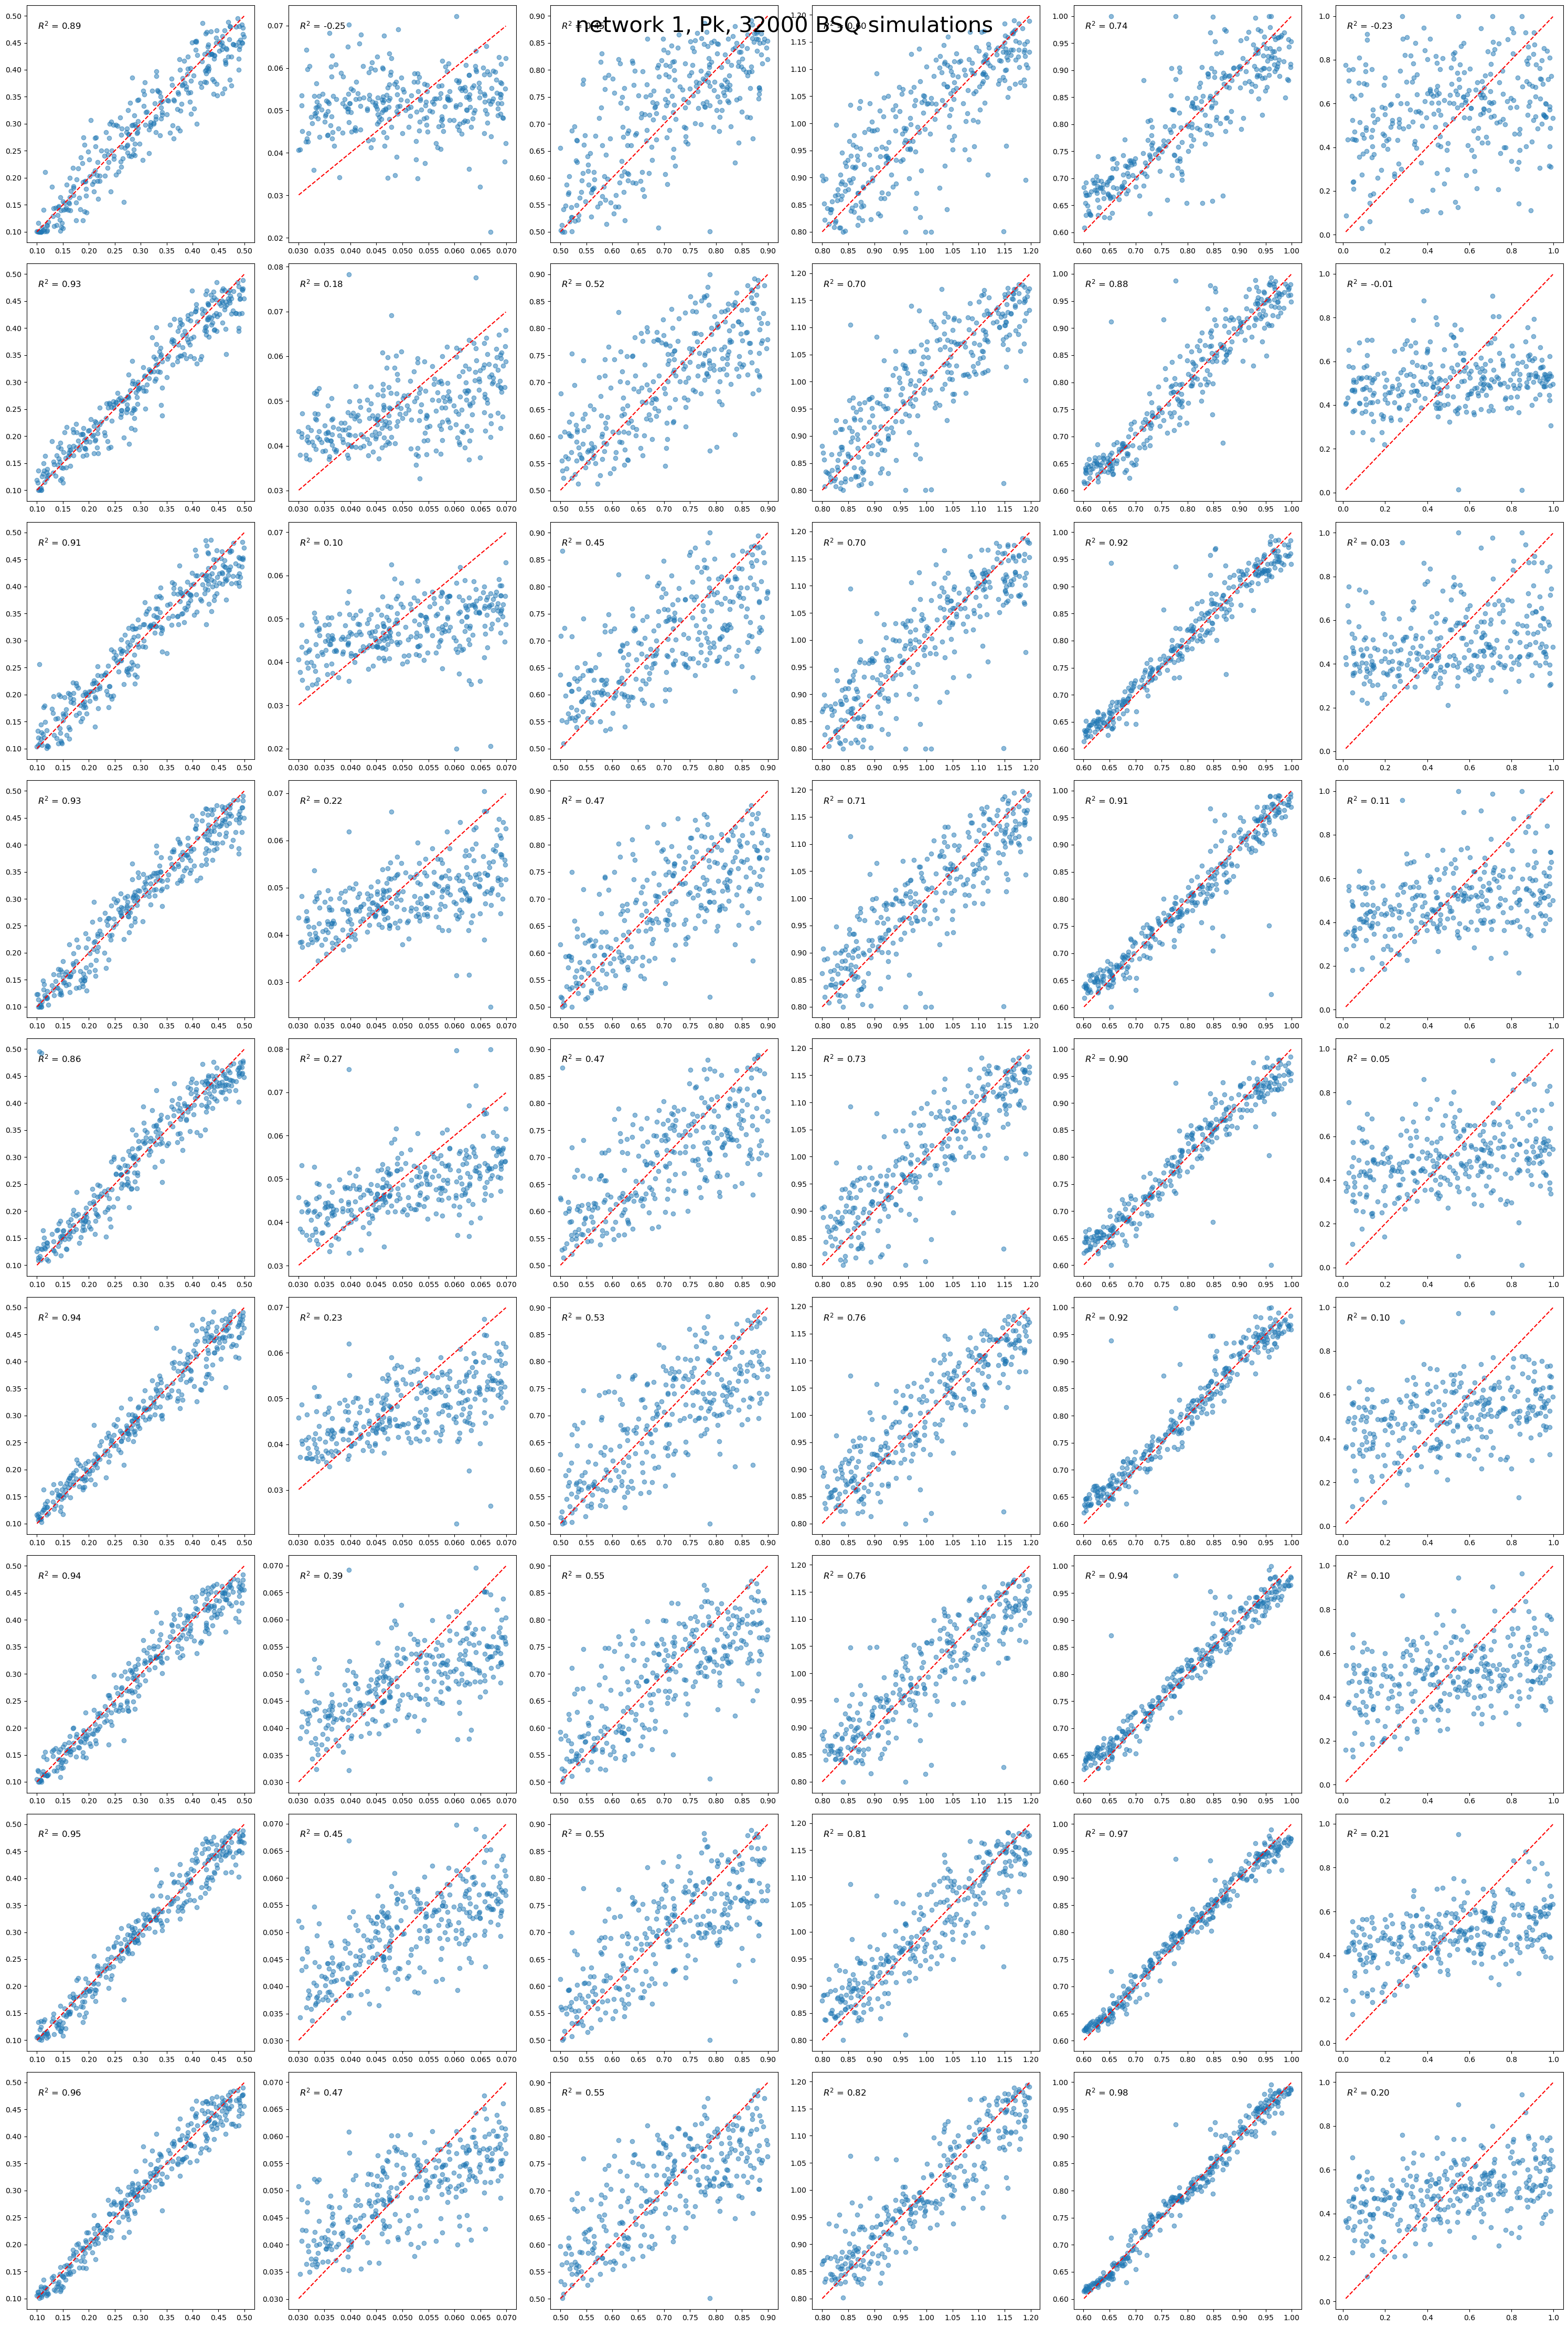

In [8]:
n_cols = num_params
n_rows = len(all_n_sims)
s = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*s, n_rows*s))

for row, n_sims in enumerate(all_n_sims):

    if cosm_type == 'BSQ':
        name = 'transfer10_network1_'+str(n_sims)+'_'+cosm_type + additional_extension
    else:
        name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set

    test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
    test_true = test[:, :num_params]     # First half (true values)
    test_predicted = test[:, num_params:]  # Second half (predicted values)
    preds = test_predicted * (maximum - minimum) + minimum
    truths = test_true * (maximum - minimum) + minimum
    
    for col in range(num_params):
        ax = axes[row, col]
        ax.scatter(truths[:, col], preds[:, col], alpha=0.5)
        ax.plot([truths[:, col].min(), truths[:, col].max()], [truths[:, col].min(), truths[:, col].max()], 'r--')
        # ax.set_title(f'{dataset_name} - {param_names[col]}')
        # axes[2][col].set_xlabel('True Values')
        # axes[row][0].set_ylabel('Predicted Values')
        r2 = r2_score(truths[:, col], preds[:, col])
        mse = mean_squared_error(truths[:, col], preds[:, col])
        ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=12)
        # ax.text(0.05, 0.9, f'$mse$ = {mse:.2f}', transform=ax.transAxes, fontsize=12)
plt.suptitle(r'network 1, Pk, 32000 BSQ simulations', size = 30)
plt.tight_layout()
# plt.savefig('transfer10_network2_Pk_1000_LC_32000_BSQ.png')
plt.show()


## Make true vs predicted plots for train, valid and test at given n sims

In [28]:
cosm_type = 'BSQ'
Pk_type = 'Pk'
n_sims = 22000
n_sims_BSQ = 0
# additional_extension = '_fixed_ft_test'
additional_extension = '_node'

In [29]:
if cosm_type == 'nwLH':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''

elif cosm_type == 'LH':
    num_params = 5
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'BSQ':
    num_params = 5
    # num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    params_ext = ''

elif cosm_type == 'LC':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{local}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -300])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 300])
    params_ext = ''

elif cosm_type == 'EQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{equilateral}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -600])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 600])
    params_ext = ''

elif cosm_type == 'nwLH_BSQ':
    num_params = 6
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$w$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
    params_ext = ''


elif cosm_type == 'fR':
    num_params = 7
    param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', 
               r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$', r'$f_{R}$']
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
    params_ext = '_lcdm'


if cosm_type == 'BSQ':
    name = 'transfer10_network1_'+str(n_sims)+'_'+cosm_type + additional_extension
else:
    name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ'  + additional_extension  #_fixed for fixed test/valid set
        


test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
test_true = test[:, :num_params]     # First half (true values)
test_predicted = test[:, num_params:]  # Second half (predicted values)

train = np.loadtxt('results/Results_train_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
train_true = train[:, :num_params]     # First half (true values)
train_predicted = train[:, num_params:]

valid = np.loadtxt('results/Results_valid_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+name+'.txt')
valid_true = valid[:, :num_params]     # First half (true values)
valid_predicted = valid[:, num_params:]

# Reverse normalization for predictions
test_predicted = test_predicted * (maximum - minimum) + minimum
train_predicted = train_predicted * (maximum - minimum) + minimum
valid_predicted = valid_predicted * (maximum - minimum) + minimum

# Reverse normalization for true values
test_true = test_true * (maximum - minimum) + minimum
train_true = train_true * (maximum - minimum) + minimum
valid_true = valid_true * (maximum - minimum) + minimum

In [30]:
print (len(test_predicted))
print(len(train_predicted))

4800
22000


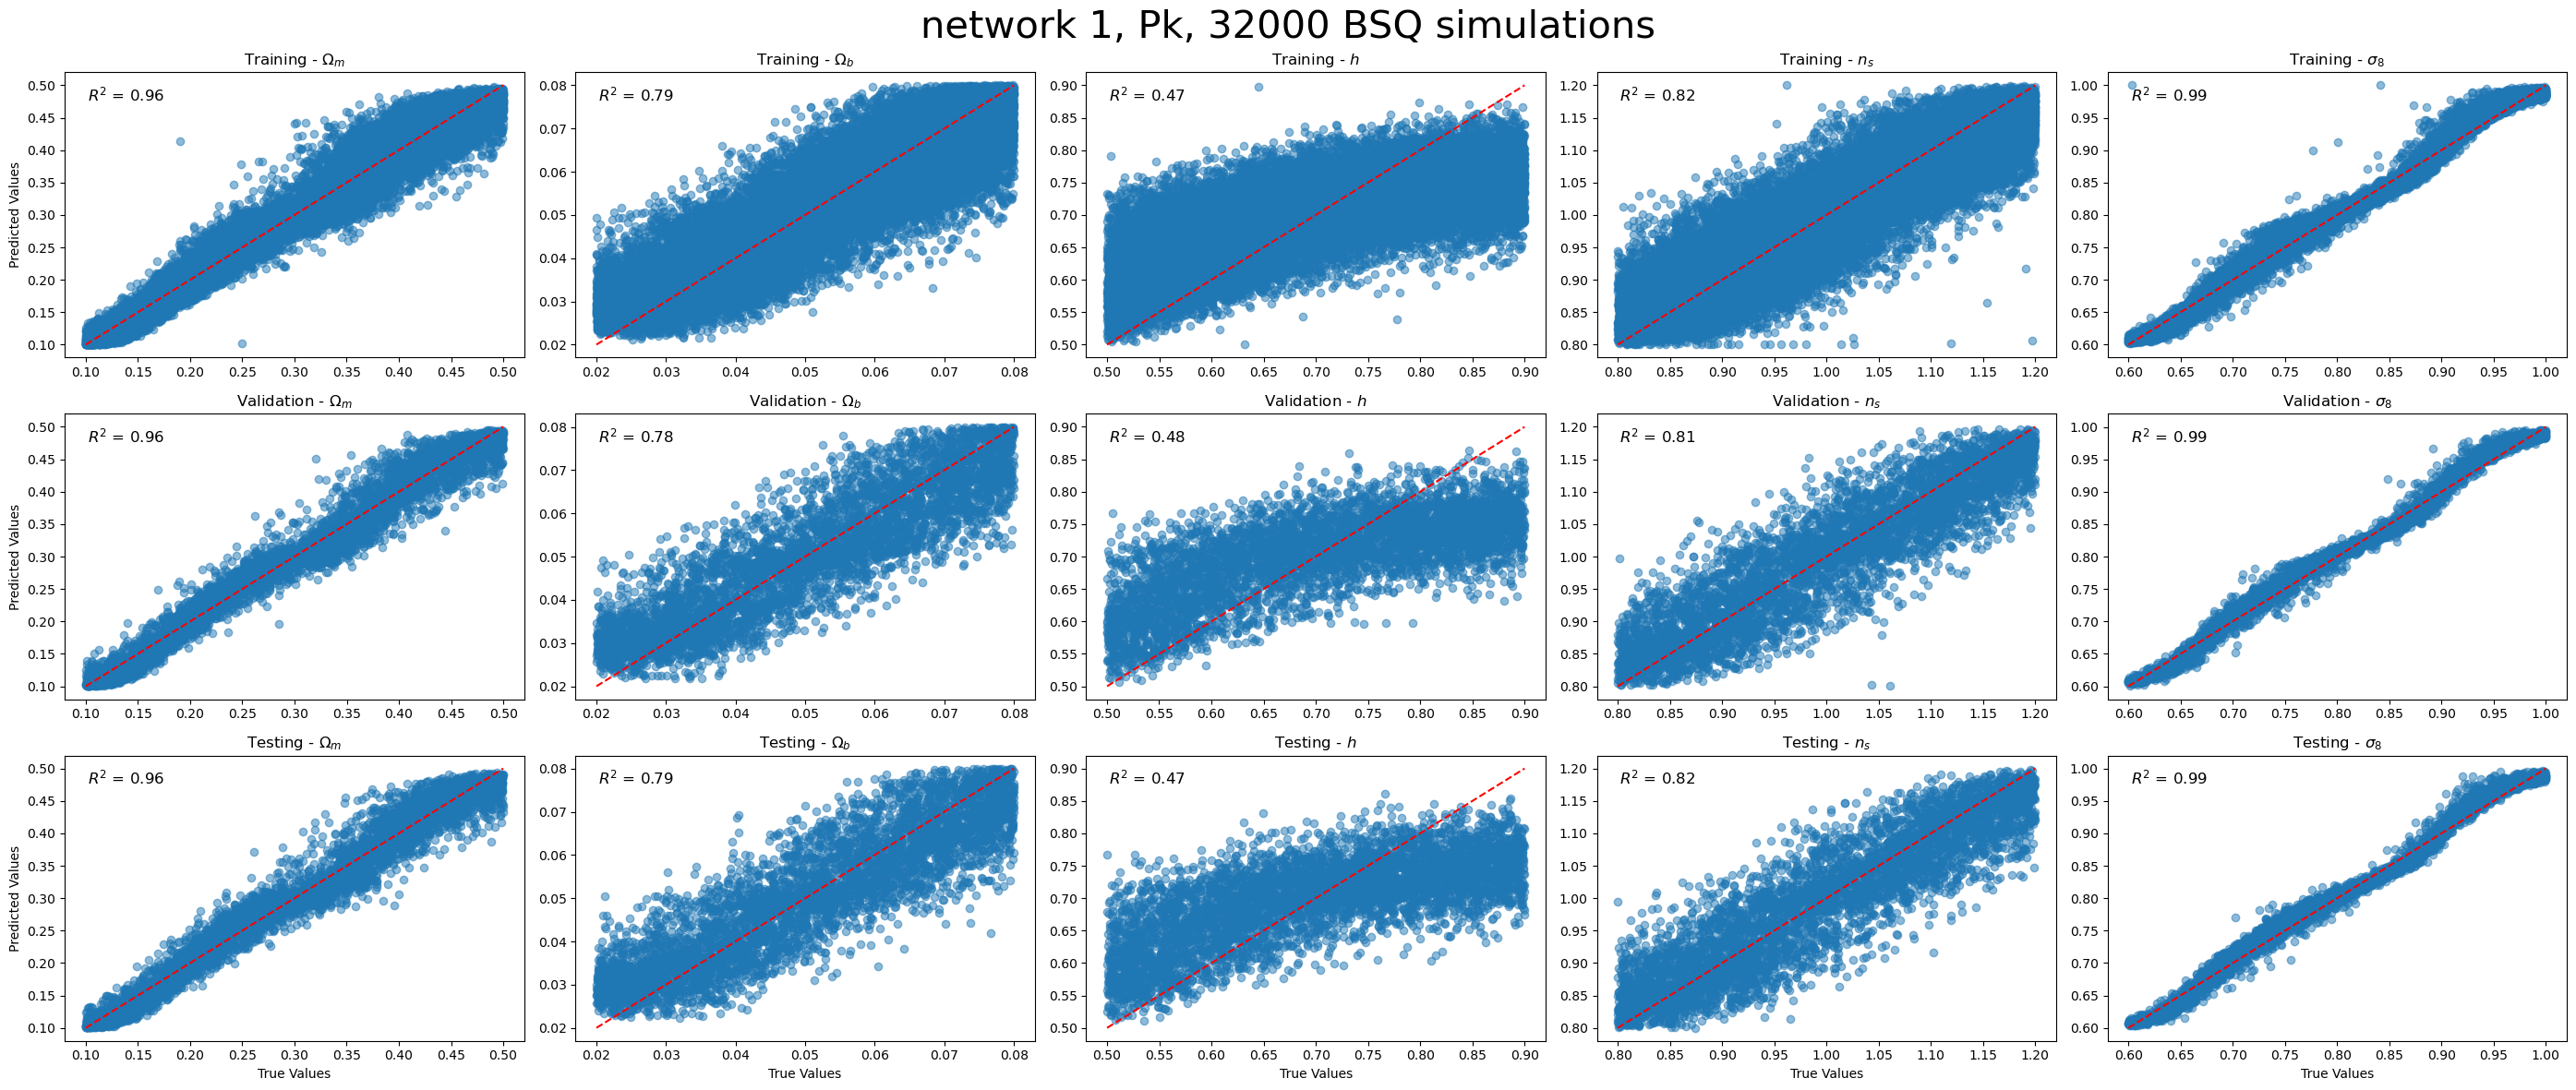

In [31]:
from sklearn.metrics import mean_squared_error
datasets = [('Training', train_predicted, train_true), 
            ('Validation', valid_predicted, valid_true), 
            ('Testing', test_predicted, test_true)]

fig, axes = plt.subplots(3, num_params, figsize=(28, 12))

for row, (dataset_name, preds, truths) in enumerate(datasets):
    for col in range(num_params):
        ax = axes[row, col]
        ax.scatter(truths[:, col], preds[:, col], alpha=0.5)
        ax.plot([truths[:, col].min(), truths[:, col].max()], [truths[:, col].min(), truths[:, col].max()], 'r--')
        ax.set_title(f'{dataset_name} - {param_names[col]}')
        axes[2][col].set_xlabel('True Values')
        axes[row][0].set_ylabel('Predicted Values')
        r2 = r2_score(truths[:, col], preds[:, col])
        mse = mean_squared_error(truths[:, col], preds[:, col])
        ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=12)
        # ax.text(0.05, 0.9, f'$mse$ = {mse:.2f}', transform=ax.transAxes, fontsize=12)
plt.suptitle(r'network 1, Pk, 32000 BSQ simulations', size = 30)
plt.tight_layout()
# plt.savefig('transfer10_network2_Pk_1000_LC_32000_BSQ.png')
plt.show()
